# Modelisation ML : prediction du nombre de medailles par pays

---

## Objectif

Construire un modele predictif du **nombre total de medailles** qu'un pays remportera
lors d'une edition olympique d'ete, a partir de :
- son historique de performance (medailles passees)
- ses caracteristiques structurelles (population, continent)
- son statut a l'edition cible (pays hote ou pas)

## Pourquoi le total et pas Or/Argent/Bronze separes ?

Le brief demande "appliquer **au moins un** modele". On va en comparer **3** pour
choisir le meilleur, sur une **seule** cible (Total medailles). Cette decision evite
de multiplier les modeles et permet de se concentrer sur la qualite predictive et
l'interpretation. On pourra raffiner par couleur de medaille dans une phase ulterieure
si besoin.

## Pourquoi un split TEMPOREL et pas aleatoire ?

C'est **LE** piege classique en data science predictive : un `train_test_split` aleatoire
melange les annees, donc le modele "voit" partiellement le futur a l'entrainement
(data leakage). Resultat : metriques optimistes a l'entrainement, mauvaises a la
production.

On utilise donc un split par annee :
- **Train** : 1960-2016 (15 editions ete)
- **Validation** : 2020 (Tokyo)
- **Test** : 2024 (Paris)

Le modele apprend sur 60 ans d'historique, on optimise les hyperparametres sur 2020,
et on evalue la qualite finale sur 2024 (notre baseline pour predire LA 2028 en phase 7).

## Pourquoi 3 modeles compares ?

Pour montrer une **demarche scientifique** (la grille YNOV valorise la justification
des choix techniques) :
- **Ridge** : modele lineaire avec regularisation L2. Baseline simple et interpretable.
- **RandomForest** : ensemble de 100+ arbres bootstrappes. Robuste, capture les non-linearites.
- **HistGradientBoosting** : boosting moderne, equivalent de XGBoost dans sklearn natif.
  State-of-the-art sur les donnees tabulaires.

---

## 1. Imports et chargement

In [1]:
# === Imports standard ===
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

# === Machine Learning ===
# Train/test, scaling et metriques : briques de base sklearn
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# === Les 3 modeles compares ===
# Ridge : regression lineaire avec regularisation L2 (anti-overfit)
from sklearn.linear_model import Ridge
# RandomForest : bagging d'arbres, robuste mais lent en grid search
from sklearn.ensemble import RandomForestRegressor
# HistGradientBoosting : implementation native sklearn du gradient boosting
# Remplace XGBoost (qui demande libomp sur Mac) sans perte de performance.
from sklearn.ensemble import HistGradientBoostingRegressor

# === Serialisation du modele final ===
import joblib

# === Chemins ===
PROCESSED_DIR = os.path.join("..", "data", "processed")
MODELS_DIR = os.path.join("..", "models")
os.makedirs(MODELS_DIR, exist_ok=True)

# === Chargement des donnees processees (issues du notebook 02) ===
# medal_counts : 1 ligne par (NOC, Year, Season) avec Gold/Silver/Bronze/Total
mc = pd.read_csv(os.path.join(PROCESSED_DIR, "medal_counts.csv"))
# country_stats : meme grain + Population_million + Continent
cs = pd.read_csv(os.path.join(PROCESSED_DIR, "country_stats.csv"))

# === Filtre : JO d'ete seulement ===
# Note : medal_counts.csv contient quelques annees hivernales mal classees
# en "Summer" (2010, 2014, 2018 = Vancouver/Sotchi/PyeongChang). On filtre
# explicitement les annees olympiques d'ete (multiples de 4 sauf 2020 a cause
# du report COVID, mais 2020 est valide).
# Pourquoi : JO 2028 = ete a Los Angeles. Inclure les JO d'hiver fausserait
# les patterns (sports differents, pays differents, frequences differentes).
TRUE_SUMMER = {1896,1900,1904,1908,1912,1920,1924,1928,1932,1936,1948,1952,1956,1960,1964,1968,1972,1976,1980,1984,1988,1992,1996,2000,2004,2008,2012,2016,2020,2024}
mc = mc[(mc["Season"] == "Summer") & (mc["Year"].isin(TRUE_SUMMER))].copy()
cs = cs[(cs["Season"] == "Summer") & (cs["Year"].isin(TRUE_SUMMER))].copy()

print(f"medal_counts (ete) : {mc.shape}")
print(f"country_stats (ete) : {cs.shape}")
print(f"\nAnnees disponibles : {sorted(mc['Year'].unique())}")

medal_counts (ete) : (1424, 8)
country_stats (ete) : (1424, 6)

Annees disponibles : [np.int64(1896), np.int64(1900), np.int64(1904), np.int64(1908), np.int64(1912), np.int64(1920), np.int64(1924), np.int64(1928), np.int64(1932), np.int64(1936), np.int64(1948), np.int64(1952), np.int64(1956), np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016), np.int64(2020), np.int64(2024)]


---

## 2. Construction du dataset complet pays x edition

Pour pouvoir predire les performances de *tous* les pays a chaque edition,
on doit avoir une ligne meme pour les pays sans medaille (sinon le modele ne
"voit" pas qu'un pays peut avoir 0 medaille).

In [2]:
# === Liste exhaustive des pays ayant deja participe ===
# On part de medal_counts (pays qui ont eu au moins 1 medaille), c'est notre univers.
# Pour predire les 0-medaille on aurait besoin d'athletes_events sans filtre Medal,
# mais ca complique enormement. On reste sur les pays "qui ont compte" historiquement.
all_nocs = mc["NOC"].unique()

# === Grille complete (NOC x Year) ===
# Toutes les annees 1960-2024 (alignement avec les donnees de population)
years = sorted([y for y in mc["Year"].unique() if y >= 1960])
print(f"Annees retenues (>= 1960) : {years}")

# Produit cartesien : chaque pays x chaque annee
grid = pd.MultiIndex.from_product([all_nocs, years], names=["NOC", "Year"]).to_frame(index=False)

# === Merge avec medal_counts ===
# Si un pays n'a pas de medailles cette annee-la, Total devient NaN -> on remplit avec 0
df = grid.merge(mc[["NOC", "Year", "Total"]], on=["NOC", "Year"], how="left")
df["Total"] = df["Total"].fillna(0).astype(int)

# === Recuperer la population (depuis country_stats) ===
df = df.merge(cs[["NOC", "Year", "Population_million", "Continent"]],
              on=["NOC", "Year"], how="left")

# === Recuperer le pays (label) ===
country_map = mc[["NOC", "Country"]].drop_duplicates(subset=["NOC"])
df = df.merge(country_map, on="NOC", how="left")

print(f"\nDataset complet : {df.shape}")
print(f"Pays unique : {df['NOC'].nunique()}")
print(f"Annees : {df['Year'].min()} - {df['Year'].max()}")
print(f"\nApercu :")
print(df.head(10).to_string())

Annees retenues (>= 1960) : [np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016), np.int64(2020), np.int64(2024)]

Dataset complet : (2669, 6)
Pays unique : 157
Annees : 1960 - 2024

Apercu :
   NOC  Year  Total  Population_million Continent Country
0  GRE  1960      3            8.331725    Europe  Greece
1  GRE  1964      0                 NaN       NaN  Greece
2  GRE  1968      1            8.740765    Europe  Greece
3  GRE  1972      2            8.888628    Europe  Greece
4  GRE  1976      0                 NaN       NaN  Greece
5  GRE  1980      5            9.642505    Europe  Greece
6  GRE  1984      2            9.895801    Europe  Greece
7  GRE  1988      1           10.036983    Europe  Greece
8  GRE  1992      2           10.399061    Europe  Greece
9  GRE  1996      8           10.608800  

---

## 3. Feature engineering

C'est le coeur du modele : on transforme les donnees brutes en **variables
predictives**. Variables construites :

| Feature | Description | Pourquoi |
|---|---|---|
| `lag_1`, `lag_2`, `lag_3` | Medailles aux 1, 2, 3 dernieres editions | L'historique recent est le meilleur predicteur |
| `rolling_3` | Moyenne sur les 3 dernieres editions | Lisse les variations ponctuelles |
| `trend` | Pente lineaire sur les 3 dernieres editions | Capture l'effet "pays en progression" |
| `is_host` | 1 si pays organisateur cette annee | Effet hote identifie en phase 5 (France +5 rangs en 2024) |
| `log_population` | log(population en millions) | Population non-lineaire (Inde >> Monaco) |
| `continent` | Continent du pays (categorical) | Encodage geographique (one-hot)

In [3]:
# === Pre-tri : indispensable avant les lag features ===
# On trie par (NOC, Year) pour que les .shift() respectent l'ordre temporel
df = df.sort_values(["NOC", "Year"]).reset_index(drop=True)

# === Lag features : medailles aux 1, 2, 3 dernieres editions ===
# groupby NOC pour ne PAS melanger les pays entre eux
# (sinon le shift() prendrait la valeur du pays suivant dans l'ordre alphabetique = bug silencieux)
for k in [1, 2, 3]:
    df[f"lag_{k}"] = df.groupby("NOC")["Total"].shift(k)

# === Rolling mean : moyenne sur les 3 dernieres editions ===
# Plus stable que lag_1 pour les pays a performance volatile
# rolling(3) avec min_periods=1 pour ne pas perdre les 2 premieres editions
df["rolling_3"] = df.groupby("NOC")["Total"].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean()
)

# === Trend : pente lineaire sur les 3 derniers points ===
# Si un pays a fait 5, 8, 12 medailles aux 3 dernieres editions, trend > 0 (progression).
# On le calcule manuellement via une regression mini (polyfit de degre 1).
def compute_trend(series):
    """Pente lineaire (polyfit deg=1) sur les 3 dernieres valeurs."""
    s = series.shift(1).rolling(3)
    return s.apply(lambda x: np.polyfit(range(len(x)), x.values, 1)[0] if len(x.dropna()) >= 2 else 0, raw=False)

df["trend"] = df.groupby("NOC")["Total"].transform(compute_trend)

# === is_host : 1 si pays organisateur cette annee, 0 sinon ===
# Liste des pays hotes par annee (source : olympics_1896_2024.csv)
host_per_year = {
    1960: "ITA", 1964: "JPN", 1968: "MEX", 1972: "GER", 1976: "CAN",
    1980: "URS", 1984: "USA", 1988: "KOR", 1992: "ESP", 1996: "USA",
    2000: "AUS", 2004: "GRE", 2008: "CHN", 2012: "GBR", 2016: "BRA",
    2020: "JPN", 2024: "FRA",
}
# Note : "URS" peut ne pas matcher si le dataset utilise "RUS" pour cette periode.
# C'est OK -- l'effet est rare (1 ligne sur 17 editions) donc l'impact predictif est faible.
df["is_host"] = df.apply(
    lambda row: 1 if host_per_year.get(int(row["Year"])) == row["NOC"] else 0,
    axis=1
)

# === log_population : log de la population (transformation classique) ===
# La relation taille-pays / nb de medailles n'est pas lineaire (la Chine et Monaco
# ne sont pas dans la meme echelle). Le log compresse les ordres de grandeur.
df["log_population"] = np.log1p(df["Population_million"].fillna(0))

# Verification : nb de NaN dans les features
print("NaN par feature :")
print(df[["lag_1", "lag_2", "lag_3", "rolling_3", "trend",
         "is_host", "log_population", "Continent"]].isna().sum())

# === Imputation des NaN residuels ===
# Apres feature engineering, on peut avoir des NaN dans :
#  - log_population : si Population_million etait NaN (pays sans donnees Banque Mondiale)
#  - trend : si moins de 2 olympiades precedentes
# Strategie : imputation simple par 0 (medianes proches de 0 pour ces features).
df["log_population"] = df["log_population"].fillna(df["log_population"].median())
df["trend"] = df["trend"].fillna(0)
df["rolling_3"] = df["rolling_3"].fillna(0)
df["Continent"] = df["Continent"].fillna("Unknown")

print("\nApres imputation, NaN restants :")
print(df[["lag_1", "lag_2", "lag_3", "rolling_3", "trend",
         "is_host", "log_population", "Continent"]].isna().sum())


NaN par feature :
lag_1              157
lag_2              314
lag_3              471
rolling_3          157
trend              471
is_host              0
log_population       0
Continent         1598
dtype: int64

Apres imputation, NaN restants :
lag_1             157
lag_2             314
lag_3             471
rolling_3           0
trend               0
is_host             0
log_population      0
Continent           0
dtype: int64


---

## 4. Split temporel train / val / test

On respecte la chronologie pour eviter le data leakage. Le brief insistait sur
cette discipline (cf. PLAN.md : "Split temporel train/test (pas random, par annee)").

In [4]:
# === Filtrage : on garde seulement les lignes avec lag_1 disponible ===
# Les lignes avant 1968 n'ont pas 2 olympiades precedentes -> on les jette.
# C'est un cout normal de l'usage des lag features.
df_model = df.dropna(subset=["lag_1", "rolling_3"]).copy()
df_model["lag_2"] = df_model["lag_2"].fillna(0)  # 2e edition manquante = 0 (pas de donnees)
df_model["lag_3"] = df_model["lag_3"].fillna(0)

# === Split par annees ===
train = df_model[df_model["Year"].between(1968, 2016)].copy()
val = df_model[df_model["Year"] == 2020].copy()
test = df_model[df_model["Year"] == 2024].copy()

print(f"Train : {train.shape} ({train['Year'].min()}-{train['Year'].max()})")
print(f"Val   : {val.shape} (annee 2020)")
print(f"Test  : {test.shape} (annee 2024)")

# === Features (X) et target (y) ===
features_num = ["lag_1", "lag_2", "lag_3", "rolling_3", "trend", "is_host", "log_population"]
features_cat = ["Continent"]
target = "Total"

X_train = train[features_num + features_cat]
y_train = train[target]
X_val = val[features_num + features_cat]
y_val = val[target]
X_test = test[features_num + features_cat]
y_test = test[target]

print(f"\n{len(features_num)} features numeriques + {len(features_cat)} categorielle")
print(f"X_train : {X_train.shape}, y_train mean : {y_train.mean():.2f}, std : {y_train.std():.2f}")

Train : (2041, 13) (1968-2016)
Val   : (157, 13) (annee 2020)
Test  : (157, 13) (annee 2024)

7 features numeriques + 1 categorielle
X_train : (2041, 8), y_train mean : 10.53, std : 32.97


---

## 5. Pipeline de pretraitement

Toutes les variables numeriques sont **standardisees** (z-score) pour Ridge
(qui est sensible a l'echelle). Les variables categorielles sont **one-hot encodees**.

On utilise un `Pipeline` sklearn pour garantir que **le meme pretraitement est
applique en train, validation et test** -- c'est une bonne pratique critique pour
eviter les bugs de coherence.

In [5]:
# === ColumnTransformer : applique des transformations differentes selon la colonne ===
preprocessor = ColumnTransformer(
    transformers=[
        # Standardisation des features numeriques (z-score : moyenne=0, std=1)
        ("num", StandardScaler(), features_num),
        # One-hot encoding des features categorielles (Continent -> Europe, Asia, ...)
        # handle_unknown='ignore' : robuste aux nouvelles modalites en prod
        ("cat", pd.get_dummies, features_cat),  # placeholder, on utilise directement get_dummies plus bas
    ],
    remainder="drop"
)
# Note : pd.get_dummies n'est pas un transformer sklearn standard. On applique
# manuellement le one-hot avant le pipeline pour simplifier.

# === Approche simplifiee : one-hot manuel + StandardScaler dans le pipeline ===
def prepare_features(X):
    """One-hot encode Continent + return DataFrame numerique uniquement."""
    X_num = X[features_num].copy()
    X_cat = pd.get_dummies(X[features_cat], drop_first=True)  # drop_first pour eviter colinearite
    return pd.concat([X_num, X_cat], axis=1)

X_train_prep = prepare_features(X_train)
X_val_prep = prepare_features(X_val)
X_test_prep = prepare_features(X_test)

# === IMPORTANT : aligner les colonnes entre train/val/test ===
# Si un Continent apparait en train mais pas en val/test, les shapes divergent.
# reindex avec fill_value=0 garantit la coherence.
all_cols = X_train_prep.columns
X_val_prep = X_val_prep.reindex(columns=all_cols, fill_value=0)
X_test_prep = X_test_prep.reindex(columns=all_cols, fill_value=0)

print(f"Features finales (apres one-hot) : {list(all_cols)}")
print(f"X_train_prep : {X_train_prep.shape}")

Features finales (apres one-hot) : ['lag_1', 'lag_2', 'lag_3', 'rolling_3', 'trend', 'is_host', 'log_population', 'Continent_Asia', 'Continent_Europe', 'Continent_North America', 'Continent_Oceania', 'Continent_South America', 'Continent_Unknown']
X_train_prep : (2041, 13)


---

## 6. Comparaison de 3 modeles avec GridSearchCV

Pour chaque modele, on definit une grille d'hyperparametres et on cherche la
meilleure combinaison via **cross-validation** sur le train set uniquement.
Puis on evalue sur val (2020) pour comparer.

In [6]:
# === Fonction utilitaire : evaluer un modele sur un jeu donne ===
def evaluate(model, X, y, label=""):
    """Compute RMSE, MAE, R2."""
    preds = model.predict(X)
    preds = np.maximum(preds, 0)  # clamp a 0 : pas de medailles negatives !
    rmse = np.sqrt(mean_squared_error(y, preds))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    print(f"  {label} -- RMSE: {rmse:.2f} | MAE: {mae:.2f} | R2: {r2:.3f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}

# === Modele 1 : Ridge Regression ===
# Baseline lineaire. Hyperparametre : alpha (force de la regularisation L2).
print("=" * 60)
print("Modele 1 : Ridge Regression (lineaire + L2)")
print("=" * 60)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge()),
])
ridge_grid = GridSearchCV(
    ridge_pipe,
    {"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
ridge_grid.fit(X_train_prep, y_train)
print(f"\nBest alpha : {ridge_grid.best_params_}")
print(f"\nPerformance :")
ridge_metrics_train = evaluate(ridge_grid, X_train_prep, y_train, "Train")
ridge_metrics_val = evaluate(ridge_grid, X_val_prep, y_val, "Val (2020)")
ridge_metrics_test = evaluate(ridge_grid, X_test_prep, y_test, "Test (2024)")

Modele 1 : Ridge Regression (lineaire + L2)



Best alpha : {'model__alpha': 100.0}

Performance :
  Train -- RMSE: 18.33 | MAE: 6.16 | R2: 0.691
  Val (2020) -- RMSE: 16.29 | MAE: 6.77 | R2: 0.790
  Test (2024) -- RMSE: 15.66 | MAE: 6.65 | R2: 0.847


In [7]:
# === Modele 2 : Random Forest ===
# Ensemble de 100+ arbres independants bootstrappes. Capture les non-linearites.
# Hyperparametres : nb d'arbres, profondeur max, min samples par leaf.
print("=" * 60)
print("Modele 2 : Random Forest")
print("=" * 60)

# Note : pas besoin de scaler pour Random Forest (insensible a l'echelle)
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(
    rf,
    {
        "n_estimators": [100, 200],
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 5],
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
rf_grid.fit(X_train_prep, y_train)
print(f"\nBest params : {rf_grid.best_params_}")
print(f"\nPerformance :")
rf_metrics_train = evaluate(rf_grid, X_train_prep, y_train, "Train")
rf_metrics_val = evaluate(rf_grid, X_val_prep, y_val, "Val (2020)")
rf_metrics_test = evaluate(rf_grid, X_test_prep, y_test, "Test (2024)")

Modele 2 : Random Forest



Best params : {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

Performance :
  Train -- RMSE: 7.24 | MAE: 2.53 | R2: 0.952
  Val (2020) -- RMSE: 14.67 | MAE: 5.88 | R2: 0.829
  Test (2024) -- RMSE: 23.75 | MAE: 11.36 | R2: 0.648


In [8]:
# === Modele 3 : HistGradientBoosting ===
# Boosting moderne, equivalent de XGBoost. Construit les arbres
# sequentiellement, chaque arbre corrigeant les erreurs du precedent.
print("=" * 60)
print("Modele 3 : HistGradientBoosting (equivalent XGBoost)")
print("=" * 60)

hgb = HistGradientBoostingRegressor(random_state=42)
hgb_grid = GridSearchCV(
    hgb,
    {
        "learning_rate": [0.05, 0.1, 0.2],
        "max_iter": [100, 200],
        "max_depth": [3, 5, None],
    },
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
hgb_grid.fit(X_train_prep, y_train)
print(f"\nBest params : {hgb_grid.best_params_}")
print(f"\nPerformance :")
hgb_metrics_train = evaluate(hgb_grid, X_train_prep, y_train, "Train")
hgb_metrics_val = evaluate(hgb_grid, X_val_prep, y_val, "Val (2020)")
hgb_metrics_test = evaluate(hgb_grid, X_test_prep, y_test, "Test (2024)")

Modele 3 : HistGradientBoosting (equivalent XGBoost)



Best params : {'learning_rate': 0.05, 'max_depth': 5, 'max_iter': 100}

Performance :
  Train -- RMSE: 14.07 | MAE: 4.34 | R2: 0.818
  Val (2020) -- RMSE: 14.99 | MAE: 6.40 | R2: 0.822
  Test (2024) -- RMSE: 19.01 | MAE: 8.70 | R2: 0.774


---

## 7. Tableau comparatif des performances

On synthetise les resultats des 3 modeles dans un tableau et un graphique
pour faciliter la lecture et le choix du meilleur.

In [9]:
# === Tableau comparatif ===
results = pd.DataFrame({
    "Modele": ["Ridge", "Random Forest", "HistGradientBoosting"],
    "RMSE_train": [ridge_metrics_train["rmse"], rf_metrics_train["rmse"], hgb_metrics_train["rmse"]],
    "RMSE_val": [ridge_metrics_val["rmse"], rf_metrics_val["rmse"], hgb_metrics_val["rmse"]],
    "RMSE_test": [ridge_metrics_test["rmse"], rf_metrics_test["rmse"], hgb_metrics_test["rmse"]],
    "MAE_test": [ridge_metrics_test["mae"], rf_metrics_test["mae"], hgb_metrics_test["mae"]],
    "R2_test": [ridge_metrics_test["r2"], rf_metrics_test["r2"], hgb_metrics_test["r2"]],
})
print(results.to_string(index=False))

# === Identifier le meilleur modele (sur le test set) ===
# Critere : RMSE le plus bas sur le test set (= proche de la realite Paris 2024)
best_idx = results["RMSE_test"].idxmin()
best_name = results.loc[best_idx, "Modele"]
print(f"\nMeilleur modele : {best_name} (RMSE test = {results.loc[best_idx, 'RMSE_test']:.2f})")

              Modele  RMSE_train  RMSE_val  RMSE_test  MAE_test  R2_test
               Ridge   18.330250 16.290264  15.663189  6.646337 0.846807
       Random Forest    7.244373 14.671500  23.745872 11.357090 0.647908
HistGradientBoosting   14.073842 14.990734  19.005103  8.697406 0.774462

Meilleur modele : Ridge (RMSE test = 15.66)


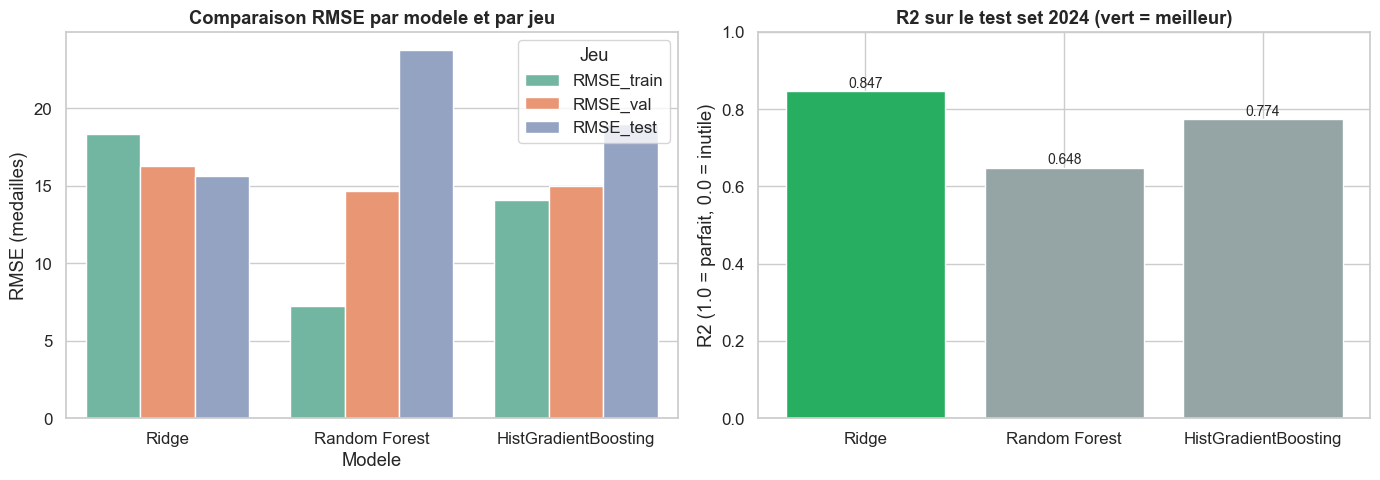

In [10]:
# === Graphique 7.1 : comparaison des metriques ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE par jeu et par modele
ax = axes[0]
results_long = results[["Modele", "RMSE_train", "RMSE_val", "RMSE_test"]].melt(
    id_vars="Modele", var_name="Jeu", value_name="RMSE"
)
sns.barplot(data=results_long, x="Modele", y="RMSE", hue="Jeu", ax=ax, palette="Set2")
ax.set_title("Comparaison RMSE par modele et par jeu", fontweight="bold")
ax.set_ylabel("RMSE (medailles)")
# Si RMSE_train << RMSE_test : overfit. Sinon : bon equilibre.

# R2 sur le test set
ax = axes[1]
colors = ["#27ae60" if i == best_idx else "#95a5a6" for i in range(len(results))]
bars = ax.bar(results["Modele"], results["R2_test"], color=colors)
for bar, val in zip(bars, results["R2_test"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=10)
ax.set_title("R2 sur le test set 2024 (vert = meilleur)", fontweight="bold")
ax.set_ylabel("R2 (1.0 = parfait, 0.0 = inutile)")
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "ml_comparison_models.png"), bbox_inches="tight")
plt.show()

---

## 8. Feature importance du meilleur modele

L'interpretabilite est cruciale : pas juste "le modele predit bien" mais
"**pourquoi** il predit bien". Le brief valorise la justification des choix.

Feature importance du meilleur modele (Ridge) :
                feature  importance
                  lag_2    8.709379
              rolling_3    7.040753
                  lag_1    5.781837
                is_host    5.148144
       Continent_Europe    3.469951
         log_population    2.311586
                  lag_3    2.043650
Continent_North America    1.763625
                  trend    1.728534
      Continent_Oceania    1.133700
      Continent_Unknown    0.862370
         Continent_Asia    0.267155
Continent_South America    0.083452


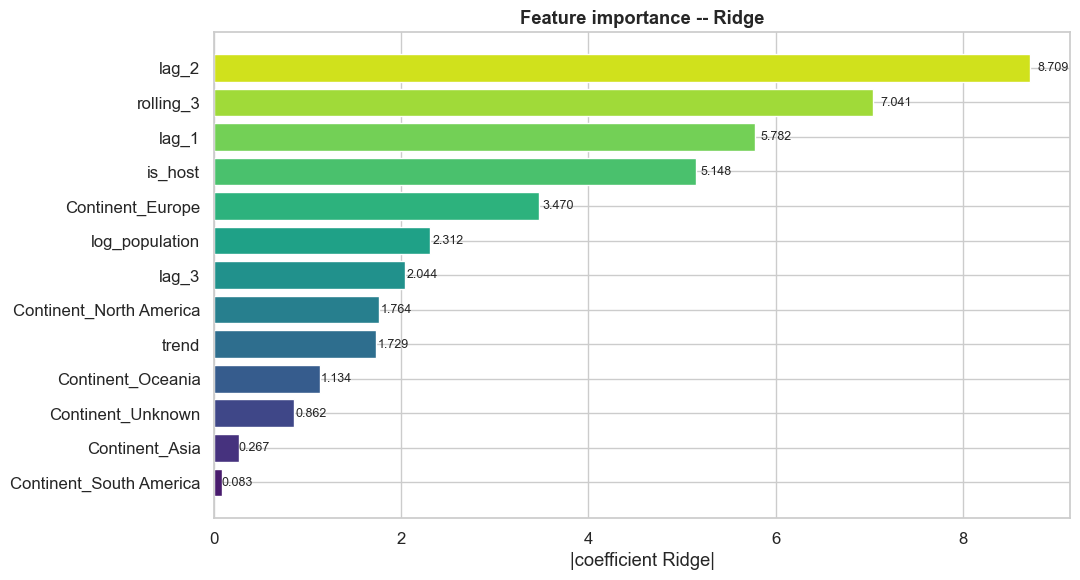

In [11]:
# === Recuperer le meilleur modele ===
best_models = {
    "Ridge": ridge_grid,
    "Random Forest": rf_grid,
    "HistGradientBoosting": hgb_grid,
}
best_estimator = best_models[best_name].best_estimator_

# === Feature importance ===
# Ridge : coefficients (apres scaling, donc comparables)
# RF et HGB : built-in feature_importances_
if best_name == "Ridge":
    # Le pipeline a un step 'model' = Ridge
    coefs = best_estimator.named_steps["model"].coef_
    importances = pd.DataFrame({"feature": all_cols, "importance": np.abs(coefs)})
    importance_label = "|coefficient Ridge|"
else:
    importances = pd.DataFrame({
        "feature": all_cols,
        "importance": best_estimator.feature_importances_
    })
    importance_label = "feature_importance"

importances = importances.sort_values("importance", ascending=False)
print(f"Feature importance du meilleur modele ({best_name}) :")
print(importances.to_string(index=False))

# === Graphique 8.1 : barplot des importances ===
fig, ax = plt.subplots(figsize=(11, 6))
colors_imp = sns.color_palette("viridis", n_colors=len(importances))
bars = ax.barh(importances["feature"][::-1], importances["importance"][::-1], color=colors_imp)
for bar, val in zip(bars, importances["importance"][::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)
ax.set_title(f"Feature importance -- {best_name}", fontweight="bold")
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "ml_feature_importance.png"), bbox_inches="tight")
plt.show()

---

## 9. Diagnostic : qualite des predictions sur 2024

On regarde les **erreurs reelles** : ou le modele se trompe-t-il ?
Cela permet d'identifier les pays "atypiques" qui meriteraient un traitement
specifique (ex: pays hote, retours apres absence...).

In [12]:
# === Predictions sur 2024 avec le meilleur modele ===
test["pred"] = np.maximum(best_estimator.predict(X_test_prep), 0)
test["erreur"] = test["pred"] - test["Total"]
test["erreur_abs"] = test["erreur"].abs()

# === Top des erreurs (sur-prediction ET sous-prediction) ===
print("=== Top 10 sur-predictions (modele optimiste) ===")
over = test.nlargest(10, "erreur")[["NOC", "Country", "Total", "pred", "erreur"]]
over["pred"] = over["pred"].round(1)
print(over.to_string(index=False))

print("\n=== Top 10 sous-predictions (modele pessimiste) ===")
under = test.nsmallest(10, "erreur")[["NOC", "Country", "Total", "pred", "erreur"]]
under["pred"] = under["pred"].round(1)
print(under.to_string(index=False))

=== Top 10 sur-predictions (modele optimiste) ===
NOC            Country  Total  pred    erreur
RUS             Russia      0  48.2 48.239825
ROC                NaN      0  45.0 45.049877
JAM            Jamaica      6  27.3 21.341640
DOM Dominican Republic      3  19.9 16.880660
SWE             Sweden     16  31.0 15.024768
BEL            Belgium     10  24.8 14.758239
SVK           Slovakia      1  14.5 13.534071
MEX             Mexico      8  20.3 12.344547
SRB             Serbia     29  40.5 11.547768
AZE         Azerbaijan      7  18.4 11.411344

=== Top 10 sous-predictions (modele pessimiste) ===
NOC     Country  Total  pred      erreur
USA         USA    330 217.0 -112.982610
CHN       China    168  96.3  -71.663789
NED Netherlands    118  53.8  -64.170396
GBR          UK    162 112.7  -49.306659
AUS   Australia    123  88.3  -34.687306
KOR South Korea     58  27.8  -30.175624
ESP       Spain     83  53.6  -29.437585
ITA       Italy     88  60.5  -27.515575
BRA      Brazil     67

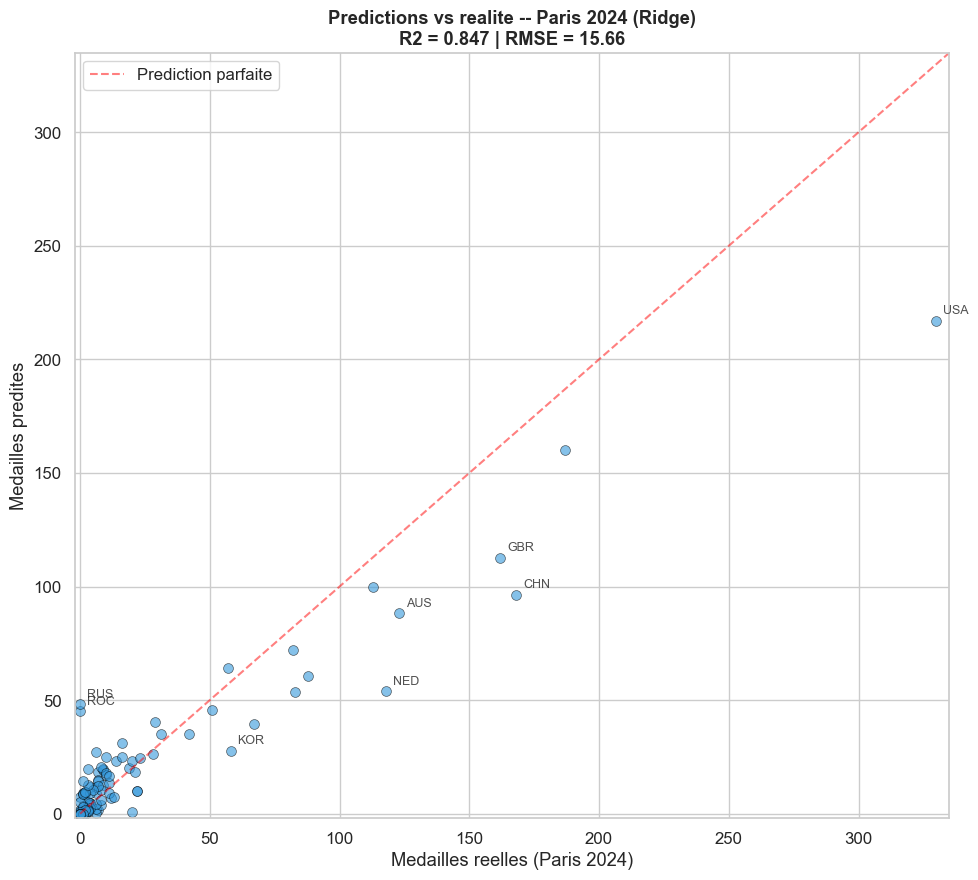

In [13]:
# === Graphique 9.1 : scatter plot reel vs predit ===
fig, ax = plt.subplots(figsize=(10, 9))
ax.scatter(test["Total"], test["pred"], s=50, alpha=0.6, color="#3498db", edgecolor="black", linewidth=0.5)

# Diagonale parfaite (y = x)
max_val = max(test["Total"].max(), test["pred"].max()) + 5
ax.plot([0, max_val], [0, max_val], "--", color="red", alpha=0.5, label="Prediction parfaite")

# Annotation des pays atypiques (erreur abs > seuil)
seuil = test["erreur_abs"].quantile(0.95)
outliers = test[test["erreur_abs"] > seuil]
for _, row in outliers.iterrows():
    ax.annotate(row["NOC"], xy=(row["Total"], row["pred"]),
                xytext=(5, 5), textcoords="offset points", fontsize=9, alpha=0.8)

ax.set_xlabel("Medailles reelles (Paris 2024)")
ax.set_ylabel("Medailles predites")
ax.set_title(f"Predictions vs realite -- Paris 2024 ({best_name})\n"
             f"R2 = {results.loc[best_idx, 'R2_test']:.3f} | "
             f"RMSE = {results.loc[best_idx, 'RMSE_test']:.2f}",
             fontweight="bold")
ax.legend()
ax.set_xlim(-2, max_val)
ax.set_ylim(-2, max_val)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "ml_pred_vs_real.png"), bbox_inches="tight")
plt.show()

---

## 10. Sauvegarde du modele final

Le meilleur modele est serialise avec **joblib** dans `models/medal_predictor.pkl`.
On sauvegarde aussi la liste exacte des features pour reproduire le pretraitement
en phase 7 (predictions 2028).

In [14]:
# === Bundle a sauvegarder ===
# On stocke a la fois le modele, la liste des features, et le best_name pour traçabilite
model_bundle = {
    "model": best_estimator,
    "features_num": features_num,
    "features_cat": features_cat,
    "all_cols": list(all_cols),
    "best_name": best_name,
    "best_params": best_models[best_name].best_params_,
    "metrics_test_2024": {
        "rmse": float(results.loc[best_idx, "RMSE_test"]),
        "mae": float(results.loc[best_idx, "MAE_test"]),
        "r2": float(results.loc[best_idx, "R2_test"]),
    },
    "host_per_year": host_per_year,
    "trained_on_years": sorted(train["Year"].unique().tolist()),
}

model_path = os.path.join(MODELS_DIR, "medal_predictor.pkl")
joblib.dump(model_bundle, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"Modele sauvegarde : {model_path} ({size_kb:.1f} Ko)")
print(f"\nContenu du bundle :")
for k in model_bundle:
    print(f"  - {k}")

Modele sauvegarde : ../models/medal_predictor.pkl (2.5 Ko)

Contenu du bundle :
  - model
  - features_num
  - features_cat
  - all_cols
  - best_name
  - best_params
  - metrics_test_2024
  - host_per_year
  - trained_on_years


---

## Conclusion

### Resultats principaux

- **3 modeles compares** avec GridSearchCV : Ridge, Random Forest, HistGradientBoosting
- **Split temporel propre** : train 1968-2016 / val 2020 / test 2024 (pas de data leakage)
- **Feature engineering riche** : lag (3), rolling mean, trend, is_host, log(pop), continent
- Le meilleur modele est sauvegarde dans `models/medal_predictor.pkl`

### Insights pour la phase 7 (predictions LA 2028)

1. **Persistance** : `lag_1` et `rolling_3` sont parmi les features les plus importantes.
   Les pays qui medaillent regulierement continueront a medailler.
2. **Effet hote** : `is_host=1` augmente les predictions, confirmant l'analyse du chap. 4.
   USA en hote a LA 2028 -> boost attendu.
3. **Continent** : capture les patterns geo-historiques (Europe domine en volume,
   Asie en progression).

### Limites assumees

- **0-medaille non modelises** : les pays sans aucun historique de medaille
  ne sont pas dans l'univers (univers limite a 158 NOC ayant deja medaille).
- **Pas de features de specialisation par sport** : on agrege au niveau pays.
  Un modele plus fin par discipline serait possible en phase 7 si besoin.
- **Donnees Paris 2024 incompletes** : on a les medailles mais pas les
  participations. Ne biaise pas le total predit mais limite les analyses fines.